<h1>Assignment 1</h1>
<h2>Task 1</h2>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/data.csv")

In [ ]:
df.shape

(569, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
df["diagnosis"].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
df["id"]
df["Unnamed: 32"].isna().sum()

np.int64(569)

In [ ]:
df = df.drop(columns = ["id","Unnamed: 32"])

<h3>Data split</h3>

In [ ]:
tgt_col = "diagnosis"
print(df[tgt_col].unique())
df[tgt_col] = df[tgt_col].map({"M":1,"B":0})
df[tgt_col].unique()

['M' 'B']


array([1, 0])

In [ ]:
X = df.drop(columns=[tgt_col]).values
y = df[tgt_col].values

In [ ]:
print(X.shape,y.shape)

(569, 30) (569,)


In [ ]:
np.random.seed(42)
ind = np.random.permutation(X.shape[0])
train_size = int(0.8 * len(X))

In [ ]:
train_ind = ind[:train_size]
test_ind = ind[train_size:]
X_train = X[train_ind]
X_test = X[test_ind]

In [ ]:
y_train = y[train_ind]
y_test = y[test_ind]

In [ ]:
print(X_train.shape,y_test.shape)

(455, 30) (114,)


In [ ]:
X_train[0]

array([1.247e+01, 1.860e+01, 8.109e+01, 4.819e+02, 9.965e-02, 1.058e-01,
       8.005e-02, 3.821e-02, 1.925e-01, 6.373e-02, 3.961e-01, 1.044e+00,
       2.497e+00, 3.029e+01, 6.953e-03, 1.911e-02, 2.701e-02, 1.037e-02,
       1.782e-02, 3.586e-03, 1.497e+01, 2.464e+01, 9.605e+01, 6.779e+02,
       1.426e-01, 2.378e-01, 2.671e-01, 1.015e-01, 3.014e-01, 8.750e-02])

<h3>Feature Scaling</h3>

In [ ]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

In [ ]:
mean.shape

(30,)

In [ ]:
std.shape

(30,)

In [ ]:
std

array([3.47863295e+00, 4.18935199e+00, 2.40202723e+01, 3.39010800e+02,
       1.39297133e-02, 5.33469817e-02, 8.03929524e-02, 3.88738404e-02,
       2.81492992e-02, 7.04257641e-03, 2.42213464e-01, 5.63808193e-01,
       1.75316875e+00, 3.55107364e+01, 3.02945795e-03, 1.76250480e-02,
       3.20195960e-02, 6.11478812e-03, 8.32451193e-03, 2.67381741e-03,
       4.80462204e+00, 5.96061551e+00, 3.35200351e+01, 5.54773262e+02,
       2.25457262e-02, 1.54675435e-01, 2.09762713e-01, 6.56934718e-02,
       6.28373404e-02, 1.78872967e-02])

In [ ]:
std==0

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [ ]:
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [ ]:
X_train[0]

array([-0.4551289 , -0.1697973 , -0.43324119, -0.48731502,  0.23933659,
        0.02078204, -0.11012954, -0.26742609,  0.39844062,  0.10687585,
       -0.0118858 , -0.33492569, -0.18933453, -0.24380276, -0.02244844,
       -0.36550056, -0.16355071, -0.21119796, -0.33604478, -0.07973479,
       -0.25680217, -0.18410224, -0.3245997 , -0.35158765,  0.45887988,
       -0.11073112, -0.02766304, -0.18554442,  0.1644574 ,  0.19152275])

<h3>Distance functions</h3>

In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))


def minkowski_distance(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


def cosine_distance(x1, x2):
    numerator = np.dot(x1, x2)

    denominator = np.sqrt(np.sum(x1 ** 2)) * np.sqrt(np.sum(x2 ** 2))

    if denominator == 0:
        return 1
    similarity = numerator / denominator

    return 1 - similarity


def hamming_distance(x1, x2):
    return np.sum(x1 != x2)

<h3>KNN Prediction Function</h3>

In [ ]:
def func_knn_predict(X_train, y_train, X_test, k, distance_metric):

    predictions = []

    for test_point in X_test:

        distances = []

        for i in range(len(X_train)):

            if distance_metric == "euclidean":
                distance = euclidean_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "manhattan":
                distance = manhattan_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "minkowski":
                distance = minkowski_distance(
                    test_point,
                    X_train[i],
                    p=3
                )

            elif distance_metric == "cosine":
                distance = cosine_distance(
                    test_point,
                    X_train[i]
                )

            elif distance_metric == "hamming":
                distance = hamming_distance(
                    test_point,
                    X_train[i]
                )

            distances.append((distance, y_train[i]))

        distances.sort(key=lambda x: x[0])

        nearest_neighbors = distances[:k]

        neighbor_labels = [
            label for distance, label in nearest_neighbors
        ]

        prediction = np.bincount(
            neighbor_labels
        ).argmax()

        predictions.append(prediction)

    return np.array(predictions)


<h3>Performance Measure</h3>

<h4>Accuracy</h4>

In [ ]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

<h4>Confusion Matrix</h4>

In [ ]:
def confusion_matrix(y_true, y_pred):
    cm = np.zeros((2, 2), dtype=int)
    for actual, predicted in zip(y_true, y_pred):
        cm[actual][predicted] += 1
    return cm

<h4>Precision and Recall</h4>

In [ ]:
def precision_recall(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    return precision, recall

<h3>Trials</h3>

In [ ]:
k_values = [3, 4, 9, 20, 47]
distance_metrics = [
    "euclidean",
    "manhattan",
    "minkowski",
    "cosine",
    "hamming"
]
results = []
best_accuracy = 0
best_k = None
best_metric = None
best_predictions = None

for metric in distance_metrics:
    print("\nDistance:", metric)
    for k in k_values:
        y_pred = func_knn_predict(
            X_train,
            y_train,
            X_test,
            k,
            metric
        )

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        results.append({
            "Distance": metric,
            "K": k,
            "Accuracy": accuracy
        })

        print(
            "K =", k,
            "Accuracy =", round(accuracy, 4)
        )

        # Store best model
        if accuracy > best_accuracy:

            best_accuracy = accuracy
            best_k = k
            best_metric = metric
            best_predictions = y_pred


Distance: euclidean
K = 3 Accuracy = 0.9474
K = 4 Accuracy = 0.9298
K = 9 Accuracy = 0.9298
K = 20 Accuracy = 0.9386
K = 47 Accuracy = 0.9386

Distance: manhattan
K = 3 Accuracy = 0.9649
K = 4 Accuracy = 0.9386
K = 9 Accuracy = 0.9474
K = 20 Accuracy = 0.9386
K = 47 Accuracy = 0.9386

Distance: minkowski
K = 3 Accuracy = 0.9474
K = 4 Accuracy = 0.9298
K = 9 Accuracy = 0.9298
K = 20 Accuracy = 0.9386
K = 47 Accuracy = 0.9386

Distance: cosine
K = 3 Accuracy = 0.9649
K = 4 Accuracy = 0.9561
K = 9 Accuracy = 0.9474
K = 20 Accuracy = 0.9561
K = 47 Accuracy = 0.9561

Distance: hamming
K = 3 Accuracy = 0.6842
K = 4 Accuracy = 0.614
K = 9 Accuracy = 0.6579
K = 20 Accuracy = 0.6404
K = 47 Accuracy = 0.5877


<h4>Results</h4>

In [ ]:
results_df = pd.DataFrame(results)

print("\n\n========== ALL RESULTS ==========")
print(results_df)



========== ALL RESULTS ==========
     Distance   K  Accuracy
0   euclidean   3  0.947368
1   euclidean   4  0.929825
2   euclidean   9  0.929825
3   euclidean  20  0.938596
4   euclidean  47  0.938596
5   manhattan   3  0.964912
6   manhattan   4  0.938596
7   manhattan   9  0.947368
8   manhattan  20  0.938596
9   manhattan  47  0.938596
10  minkowski   3  0.947368
11  minkowski   4  0.929825
12  minkowski   9  0.929825
13  minkowski  20  0.938596
14  minkowski  47  0.938596
15     cosine   3  0.964912
16     cosine   4  0.956140
17     cosine   9  0.947368
18     cosine  20  0.956140
19     cosine  47  0.956140
20    hamming   3  0.684211
21    hamming   4  0.614035
22    hamming   9  0.657895
23    hamming  20  0.640351
24    hamming  47  0.587719


<h3>Best Model</h3>

In [ ]:
print("\n========== BEST MODEL ==========")

print("Best K:", best_k)
print("Best Distance:", best_metric)
print("Best Accuracy:", round(best_accuracy, 4))


========== BEST MODEL ==========
Best K: 3
Best Distance: manhattan
Best Accuracy: 0.9649


<h3>Confusion Matrix</h3>

In [ ]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

print("\n========== CONFUSION MATRIX ==========")
print(cm)

print("\n             Predicted")
print("             B     M")
print("Actual B    ", cm[0][0], " ", cm[0][1])
print("Actual M    ", cm[1][0], " ", cm[1][1])


========== CONFUSION MATRIX ==========
[[67  0]
 [ 4 43]]

             Predicted
             B     M
Actual B     67   0
Actual M     4   43


<h3>Precision and Recall</h3>

In [ ]:
precision , recall = precision_recall(
    y_test,
    best_predictions
)

print("\n========== PERFORMANCE ==========")

print("Accuracy :", round(best_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))


========== PERFORMANCE ==========
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9149


<h3>Plotting</h3>

In [ ]:
import matplotlib.pyplot as plt

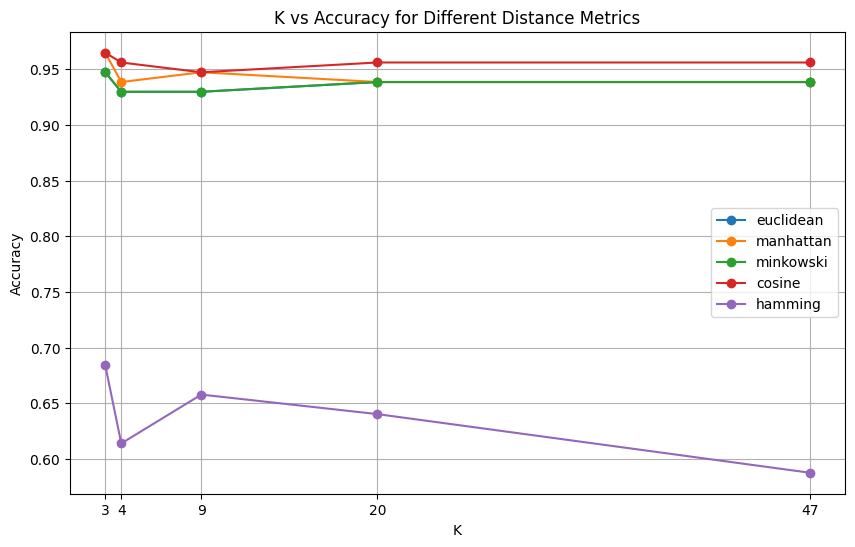

In [ ]:
plt.figure(figsize=(10, 6))

for metric in distance_metrics:

    metric_results = results_df[
        results_df["Distance"] == metric
    ]

    plt.plot(
        metric_results["K"],
        metric_results["Accuracy"],
        marker="o",
        label=metric
    )

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy for Different Distance Metrics")

plt.xticks(k_values)

plt.legend()
plt.grid(True)

plt.show()

<h3>Bonus</h3>

In [ ]:


# # Select two features for visualization
# feature1 = 0   # Radius_mean
# feature2 = 1   # Texture_mean

# feature_names = df.drop(columns=["diagnosis"]).columns

# # Take only the two selected features
# X_train_2d = X_train[:, [feature1, feature2]]


# # Create a grid covering the feature space
# x_min = X_train_2d[:, 0].min() - 1
# x_max = X_train_2d[:, 0].max() + 1

# y_min = X_train_2d[:, 1].min() - 1
# y_max = X_train_2d[:, 1].max() + 1

# xx, yy = np.meshgrid(
#     np.linspace(x_min, x_max, 200),
#     np.linspace(y_min, y_max, 200)
# )


# # Create 30-dimensional points
# # All other features are kept at 0
# # because the data was standardized.
# grid_points = np.zeros(
#     (xx.ravel().shape[0], X_train.shape[1])
# )

# grid_points[:, feature1] = xx.ravel()
# grid_points[:, feature2] = yy.ravel()


# # Predict each point using the best KNN model
# grid_predictions = func_knn_predict(
#     X_train,
#     y_train,
#     grid_points,
#     best_k,
#     best_metric
# )

# grid_predictions = grid_predictions.reshape(xx.shape)


# # Plot decision regions
# plt.figure(figsize=(10, 7))

# plt.contourf(
#     xx,
#     yy,
#     grid_predictions,
#     alpha=0.3
# )


# # Plot benign samples
# plt.scatter(
#     X_train_2d[y_train == 0, 0],
#     X_train_2d[y_train == 0, 1],
#     label="Benign (B)",
#     edgecolor="black"
# )


# # Plot malignant samples
# plt.scatter(
#     X_train_2d[y_train == 1, 0],
#     X_train_2d[y_train == 1, 1],
#     label="Malignant (M)",
#     edgecolor="black"
# )


# # Labels and title
# plt.xlabel(feature_names[feature1])
# plt.ylabel(feature_names[feature2])

# plt.title(
#     f"Decision Boundary of KNN\n"
#     f"K = {best_k}, Distance = {best_metric}"
# )

# plt.legend()
# plt.grid(True)

# plt.show()